In [15]:
import pandas as pd
df=pd.read_csv("gapminder.csv")
df.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [4]:
df.isnull().sum()

country      0
continent    0
year         0
lifeExp      0
pop          0
gdpPercap    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

country       object
continent     object
year           int64
lifeExp      float64
pop            int64
gdpPercap    float64
dtype: object

In [7]:
df.describe()

,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


In [9]:
# Questions:
# 1. At what rate is India's population growing over time?
# 2. What is the correlation between GDP per capita and life expectancy?
# 3. Rank countries by GDP per capita from 2007. Select the top 3.
# 4. How has life expectancy in the US changed over time?
# 5. Which countries changed most between 1952 and 2007?

In [5]:
# Q1
india_pop = df[df["country"] == "India"].copy()

growth_rates = [None]

for i in range(1, len(india_pop)):
    rate = (
        (india_pop["pop"].iloc[i] - india_pop["pop"].iloc[i-1])
        / india_pop["pop"].iloc[i-1]
        * 100
    )
    growth_rates.append(rate)

india_pop["growth_rate"] = growth_rates

india_pop[["year", "pop", "growth_rate"]]

,year,pop,growth_rate
696,1952,372000000,NaN
697,1957,409000000,9.946237
698,1962,454000000,11.002445
699,1967,506000000,11.453744
700,1972,567000000,12.055336
701,1977,634000000,11.816578
702,1982,708000000,11.671924
703,1987,788000000,11.299435
704,1992,872000000,10.659898
705,1997,959000000,9.977064


In [6]:
float(india_pop["growth_rate"].mean())

10.462891884194994

In [7]:
# Q2

correlation = df["gdpPercap"].corr(df["lifeExp"])
float(correlation)

0.5837062198659803

In [20]:
# Q3
data_2007=df[df["year"]== 2007]
rank=data_2007.sort_values("gdpPercap", ascending=False).head(3)
rank

,country,continent,year,lifeExp,pop,gdpPercap
1151,Norway,Europe,2007,80.196,4627926,49357.19017
863,Kuwait,Asia,2007,77.588,2505559,47306.98978
1367,Singapore,Asia,2007,79.972,4553009,47143.17964


In [18]:
# Q4
US_data = df[df["country"] == "United States"]
float(US_data.groupby("year")["lifeExp"].mean().iloc[0])

68.44

In [19]:
US_data = df[df["country"] == "United States"]
float(US_data.groupby("year")["lifeExp"].mean().iloc[-1])

78.242

In [21]:
US_data = df[df["country"] == "United States"]
US_data.groupby("year")["lifeExp"].mean()

year
1952    68.440
1957    69.490
1962    70.210
1967    70.760
1972    71.340
1977    73.380
1982    74.650
1987    75.020
1992    76.090
1997    76.810
2002    77.310
2007    78.242
Name: lifeExp, dtype: float64

In [22]:
# Q5

data_1952 = df[df["year"] == 1952]
data_2007 = df[df["year"] == 2007]

comparison = data_1952.merge(data_2007, on="country", suffixes=("_1952", "_2007"))
comparison["lifeExp_change"] = comparison["lifeExp_2007"] - comparison["lifeExp_1952"]

comparison.sort_values("lifeExp_change", ascending=False).head(3)

,country,continent_1952,year_1952,lifeExp_1952,pop_1952,gdpPercap_1952,continent_2007,year_2007,lifeExp_2007,pop_2007,gdpPercap_2007,lifeExp_change
96,Oman,Asia,1952,37.578,507833,1828.230307,Asia,2007,75.640,3204897,22316.192870,38.062
137,Vietnam,Asia,1952,40.412,26246839,605.066492,Asia,2007,74.249,85262356,2441.576404,33.837
59,Indonesia,Asia,1952,37.468,82052000,749.681655,Asia,2007,70.650,223547000,3540.651564,33.182


In [82]:
import matplotlib.pyplot as plt

In [ ]:
# Visuals to better understand relationships in the data

In [1]:
# GDP per Capita vs Life Expectancy

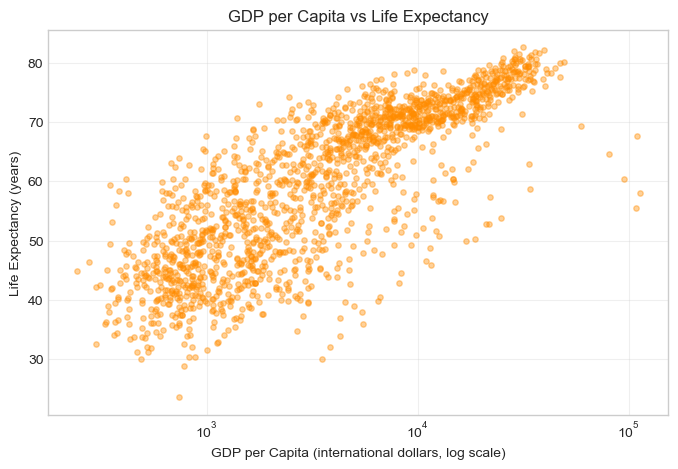

In [83]:
fig, ax= plt.subplots(figsize=(8,5))
df.plot.scatter(x="gdpPercap", y="lifeExp", ax=ax, alpha=0.4,s=15, color="darkorange")
ax.set_title("GDP per Capita vs Life Expectancy")
ax.set_xlabel("GDP per Capita (international dollars, log scale)")
ax.set_ylabel("Life Expectancy (years)")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# US Life Expectancy Over Time

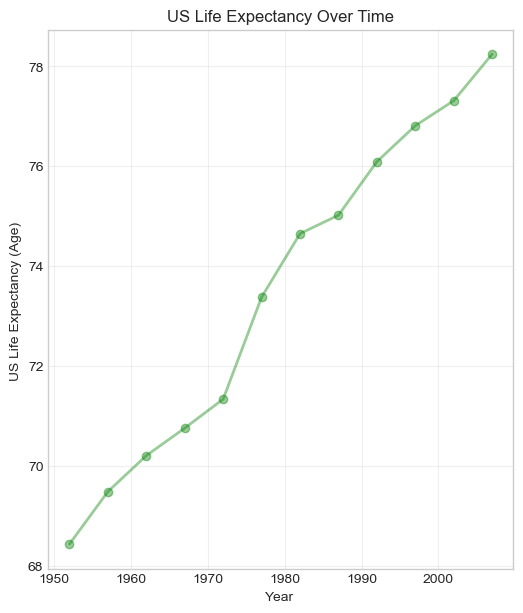

In [84]:
fig, ax= plt.subplots(figsize=(6,7))
US_lifeExp= df[df["country"]=="United States"].groupby("year")["lifeExp"].mean()
US_lifeExp.plot(x="year", y="lifeExp", ax=ax, alpha=0.4, color="green",linewidth=2, marker="o")
ax.set_title("US Life Expectancy Over Time")
ax.set_xlabel("Year ")
ax.set_ylabel("US Life Expectancy (Age) ")
ax.ticklabel_format(style='plain',axis='y')
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# India Population Over Time

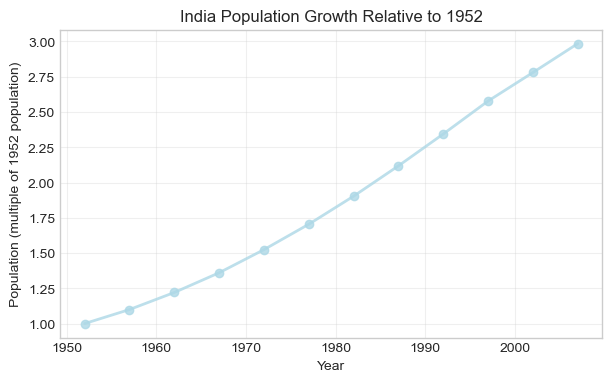

In [85]:
fig, ax= plt.subplots(figsize=(7,4))
india_pop = df[df["country"] == "India"].groupby("year")["pop"].sum()/india_pop.iloc[0]
india_pop.plot(ax=ax, color="lightblue", alpha=0.8, linewidth=2, marker="o")
ax.set_title("India Population Growth Relative to 1952")
ax.set_xlabel("Year")
ax.set_ylabel("Population (multiple of 1952 population)")
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
#Bonus Practices!

In [ ]:
#What is the average GDP per capita by continent?

continent
Oceania     18621.609223
Europe      14469.475533
Asia         7902.150428
Americas     7136.110356
Africa       2193.754578
Name: gdpPercap, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

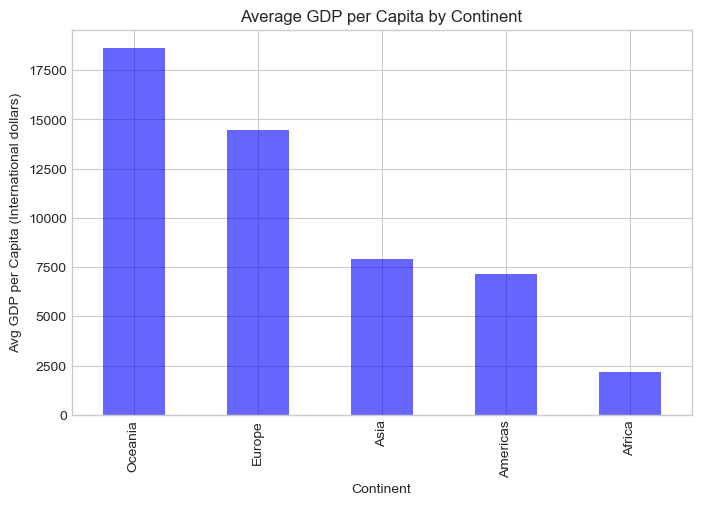

In [86]:
avg_gdp_continent= df.groupby("continent")["gdpPercap"].mean().sort_values(ascending= False)
print(avg_gdp_continent)

fig, ax = plt.subplots(figsize=(8,5))
avg_gdp_continent.plot.bar(ax=ax, color='blue', alpha=0.6)
ax.set_title("Average GDP per Capita by Continent")
ax.set_xlabel("Continent")
ax.set_ylabel("Avg GDP per Capita (International dollars)")
plt.show

In [52]:
#How was life expectancy distributed across all countries in 2007?

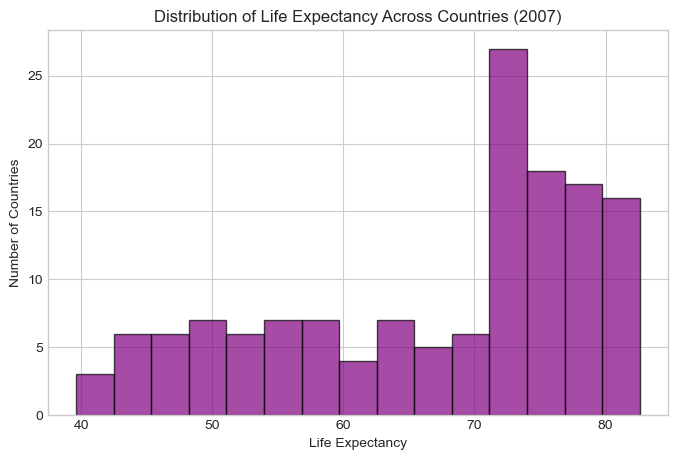

In [88]:
data_2007 = df[df["year"]==2007]
fig, ax = plt.subplots(figsize=(8,5))
data_2007["lifeExp"].plot.hist(ax=ax, bins=15, color="purple", alpha=0.7, edgecolor="black")
ax.set_title("Distribution of Life Expectancy Across Countries (2007)")
ax.set_xlabel("Life Expectancy")
ax.set_ylabel("Number of Countries")
plt.show()

In [89]:
gap_countries = data_2007[(data_2007["lifeExp"] >= 65) & (data_2007["lifeExp"] <= 70)]
print(gap_countries[["country", "lifeExp"]].sort_values("lifeExp"))
print(f"\nNumber of countries in this range: {len(gap_countries)}")

                    country  lifeExp
323                 Comoros   65.152
1175               Pakistan   65.483
1307  Sao Tome and Principe   65.528
143                 Bolivia   65.554
1007               Mongolia   66.803
839        Korea, Dem. Rep.   67.297
1559    Trinidad and Tobago   69.819

Number of countries in this range: 7
